# **Miniproyecto #1: Técnicas de Muestreo y Simulación de un Sistema de Discos Rígidos**

**Autores:** Julian Ramirez, Estefania Zapata

**Afiliación:** Instituto de Física, Universidad de Antioquia

**Curso:** Física Estadística

## **Resumen**

**Palabras clave:** Discos rígidos, Monte Carlo, cadenas de Markov, dinámica molecular por eventos, equiprobabilidad

## **2. Introducción**

<p align="center">
  <img src="figures/image.png" alt="Descripción" width="500">
</p>



Se estudia un sistema de $N$ discos rígidos idénticos, de radio $\sigma$, confinados
en una caja cuadrada bidimensional de lado unidad, con coordenadas
$(x,y) \in [0,1]\times[0,1]$. Cada disco $i$ queda completamente descrito por las
coordenadas de su centro de masa, $(x_i, y_i)$.

**Condiciones geométricas del sistema**

1. *Condición de pared (confinamiento):* el centro de cada disco debe permanecer a
   una distancia mínima $\sigma$ de cada borde de la caja, para que el disco completo
   (no solo su centro) quede contenido dentro de la caja:
   $$\sigma \leq x_i \leq 1-\sigma, \qquad \sigma \leq y_i \leq 1-\sigma$$

2. *Condición de no solapamiento:* dos discos $i,j$ no pueden
   ocupar la misma región del espacio. Como cada uno tiene radio $\sigma$, la
   distancia entre sus centros debe ser al menos $2\sigma$:
   $$\sqrt{(x_i-x_j)^2+(y_i-y_j)^2} \geq 2\sigma \qquad \forall\, i\neq j$$
  

Un *microestado* (o *configuración*) del sistema es un conjunto específico de
posiciones $\{(x_1,y_1), (x_2,y_2), \dots, (x_N,y_N)\}$ que satisface simultáneamente
las dos condiciones anteriores. El *espacio de configuraciones* es, entonces, el
subconjunto de $\mathbb{R}^{2N}$ formado por todas las combinaciones de posiciones
geométricamente permitidas (sin traslape y dentro de la caja).

En un sistema aislado en equilibrio, el postulado fundamental de la física
estadística establece que *todos los microestados accesibles al sistema son
igualmente probables*. Para nuestro sistema de discos rígidos, esto significa que,
si generamos configuraciones válidas de manera puramente aleatoria (respetando solo
las restricciones geométricas), no debería existir ninguna región del espacio de
configuraciones favorecida sobre otra. El objetivo de este miniproyecto es poner a
prueba este postulado usando tres estrategias de muestreo distintas — muestreo
directo, cadenas de Markov y dinámica molecular basada en eventos — y verificar si
las tres reproducen la misma equiprobabilidad entre un conjunto de configuraciones
de referencia $(a, b, c)$.


# 3. Marco teórico

# 4. Resultados y discusión 

### **4.1Muestreo Directo**
###  Muestreo directo — N = 4

El programa implementa la función `direct_disks_box(N, sigma)`, que genera una
configuración válida de $N$ discos dentro de la caja de lado unidad. El parámetro
`sigma` representa el **radio de cada disco**, y su valor se usa en dos lugares
del código: primero, para restringir el rango en el que se sortea cada coordenada
(`random.uniform(sigma, 1.0 - sigma)`), de modo que el disco completo —y no solo su
centro— quede contenido dentro de la caja; y segundo, como referencia para la
distancia mínima permitida entre dos centros (`2.0 * sigma`), evitando así el
traslape entre discos. La función va agregando discos uno a uno a la lista `L`: por
cada disco nuevo, calcula la distancia mínima a todos los discos ya colocados
 y, si esa distancia es menor que `2.0*sigma`, rechaza la posición
(`condition = False`, `break`) y vuelve a intentar generando toda la configuración
desde cero; si la posición es válida, la agrega a la lista. El bucle `while` externo
se repite hasta lograr colocar los $N$ discos sin conflictos.

Una vez generada una configuración con `direct_disks_box`, el programa necesita
decidir si esa configuración "coincide" con alguna de las tres configuraciones de
referencia $a$, $b$, $c$. Aquí aparece un problema numérico importante: como las
posiciones se generan a partir de números reales continuos (`random.uniform`), la probabilidad de que partícula caiga *exactamente* en una coordenada dada es numéricamente nula.Por esta razón, la identificación computacional de una configuración no puede hacerse por igualdad exacta, sino que
necesita el uso de **pequeñas cajas de tolerancia** alrededor de cada posición de
referencia: se considera que un disco generado "cae" en la posición de referencia
si su centro queda dentro de esa cajita de tamaño $2 del\_xy $. Sin
esta tolerancia, el contador de hits permanecería en cero indefinidamente, sin
importar cuántas corridas se hagan.




Esto es exactamente lo que evalúa `condition_b`,para un disco `b`
de la configuración de referencia (`conf`), se calcula la distancia de tipo
Chebyshev —el máximo entre `abs(a[0]-b[0])` y `abs(a[1]-b[1])`, es decir, la mayor
de las dos distancias por coordenada— entre `b` y cada uno de los discos `a` de la
configuración recién generada (`x_vec`), y se toma el mínimo de esas distancias
(el disco generado más cercano a `b`). `condition_b` es verdadera si ese mínimo es
menor que `del_xy`, es decir, si existe al menos un disco generado suficientemente
cerca del disco de referencia `b`.

La variable `condition_hit` se inicializa en `True` para cada configuración de
referencia, y luego se actualiza, para cada disco `b` de esa configuración,
mediante `condition_hit *= condition_b`. Al tratarse de una
multiplicación de valores booleanos (equivalentes a 1 y 0), `condition_hit` solo
permanece en `True` si `condition_b` fue `True` para **todos y cada uno** de los
discos de la configuración de referencia; basta con que uno solo de los discos no
tenga ningún disco generado cerca para que `condition_hit` quede en `False`. Es
decir, `condition_hit` es verdadera únicamente cuando la configuración generada
reproduce, dentro de la tolerancia `del_xy`, la posición de los $N$ discos de la
configuración de referencia simultáneamente — no basta con que coincida uno solo.

Finalmente, el condicional

```python
if condition_hit:
    hits[conf] += 1
```

incrementa en uno el contador `hits[conf]` correspondiente a esa configuración de
referencia (`conf_a`, `conf_b` o `conf_c`) cada vez que, en una corrida dada, la
configuración generada aleatoriamente resultó suficientemente cercana a `conf`. Al
repetir este proceso `n_runs` veces, `hits[conf]` termina acumulando el número total
de veces que el muestreo aleatorio "acertó" sobre cada configuración de referencia,
lo cual es la base para estimar y comparar sus probabilidades relativas.

Con el fin de verificar si el postulado de equiprobabilidad a priori se cumple para
el sistema de discos rígidos con $N=4$, se ejecutó el programa de muestreo directo
tres veces para cada uno de los tamaños de muestra solicitados
($n_{\text{runs}}=10^4,\,10^5,\,10^6$), registrando en cada intento el número de
*hits* obtenidos para las configuraciones de referencia $a$, $b$ y $c$, así como la
probabilidad estimada asociada a cada una ($P(\text{conf}) \approx
\text{hits}(\text{conf})/n_{\text{runs}}$). 

A continuación se presenta la tabla
correspondiente a $n_{\text{runs}}=10^4$ para $N=4$, donde se muestran los hits y
probabilidades obtenidos en cada uno de los tres intentos, junto con su media, lo
que permite evaluar tanto la equiprobabilidad entre configuraciones como la
dispersión (fluctuación) de los resultados entre repeticiones independientes.

In [13]:
import pandas as pd

# 1. Cargar el archivo con las 3 repeticiones por intento
df = pd.read_csv("data/resultados_ds_N4_1e4.csv")

# 2. Reorganizar la tabla pivoteando la columna 'Intento' hacia las columnas
df_pivot = df.pivot(
    index="Configuracion",
    columns="Intento",
    values=["Hits", "Probabilidad_Estimada"],
)

# 3. Extraer el valor de N_runs (como es el mismo para todas, lo usamos para el título)
n_runs_val = df["N_runs"].iloc[0]

# 4. Aplanar el encabezado multinivel para tener nombres de columnas limpios
df_pivot.columns = [
    "Hits (Intento 1)",
    "Hits (Intento 2)",
    "Hits (Intento 3)",
    "P (Intento 1)",
    "P (Intento 2)",
    "P (Intento 3)",
]

# 5. Calcular la media y desviación estándar de los hits y la probabilidad a través de las columnas
df_pivot["Media Hits"] = df_pivot[
    ["Hits (Intento 1)", "Hits (Intento 2)", "Hits (Intento 3)"]
].mean(axis=1)

df_pivot["Probabilidad Media (P)"] = df_pivot[
    ["P (Intento 1)", "P (Intento 2)", "P (Intento 3)"]
].mean(axis=1)

# 6. Resetear el índice para que 'Configuracion' sea una columna normal
df_final = df_pivot.reset_index()

# 7. Renderizar la tabla con Pandas Style
df_final.style.set_caption(
    f"<b>Tabla 1:</b> Resultados de Muestreo Directo para N_{{runs}} = {n_runs_val:,} (N=4) "
).format(
    {
        "Hits (Intento 1)": "{:,.0f}",
        "Hits (Intento 2)": "{:,.0f}",
        "Hits (Intento 3)": "{:,.0f}",
        "Media Hits": "{:,.1f}",
        "P (Intento 1)": "{:.6f}",
        "P (Intento 2)": "{:.6f}",
        "P (Intento 3)": "{:.6f}",
        "Probabilidad Media (P)": "{:.6f}",
    }
).hide(axis="index")

Configuracion,Hits (Intento 1),Hits (Intento 2),Hits (Intento 3),P (Intento 1),P (Intento 2),P (Intento 3),Media Hits,Probabilidad Media (P)
Configuración A,0,2,0,0.000000,0.000200,0.000000,0.7,0.000067
Configuración B,3,0,0,0.000300,0.000000,0.000000,1.0,0.000100
Configuración C,0,0,1,0.000000,0.000000,0.000100,0.3,0.000033


In [33]:
import pandas as pd

# 1. Cargar el archivo con las 3 repeticiones por intento
df = pd.read_csv("data/resultados_ds_N4_1e5.csv")

# 2. Reorganizar la tabla pivoteando la columna 'Intento' hacia las columnas
df_pivot = df.pivot(
    index="Configuracion",
    columns="Intento",
    values=["Hits", "Probabilidad_Estimada"],
)

# 3. Extraer el valor de N_runs (como es el mismo para todas, lo usamos para el título)
n_runs_val = df["N_runs"].iloc[0]

# 4. Aplanar el encabezado multinivel para tener nombres de columnas limpios
df_pivot.columns = [
    "Hits (Intento 1)",
    "Hits (Intento 2)",
    "Hits (Intento 3)",
    "P (Intento 1)",
    "P (Intento 2)",
    "P (Intento 3)",
]

# 5. Calcular la media y desviación estándar de los hits y la probabilidad a través de las columnas
df_pivot["Media Hits"] = df_pivot[
    ["Hits (Intento 1)", "Hits (Intento 2)", "Hits (Intento 3)"]
].mean(axis=1)

df_pivot["Probabilidad Media (P)"] = df_pivot[
    ["P (Intento 1)", "P (Intento 2)", "P (Intento 3)"]
].mean(axis=1)

# 6. Resetear el índice para que 'Configuracion' sea una columna normal
df_final = df_pivot.reset_index()

# 7. Renderizar la tabla con Pandas Style
df_final.style.set_caption(
    f"<b>Tabla 2:</b> Resultados de Muestreo Directo para N_{{runs}} = {n_runs_val:,} (N=4) "
).format(
    {
        "Hits (Intento 1)": "{:,.0f}",
        "Hits (Intento 2)": "{:,.0f}",
        "Hits (Intento 3)": "{:,.0f}",
        "Media Hits": "{:,.1f}",
        "P (Intento 1)": "{:.6f}",
        "P (Intento 2)": "{:.6f}",
        "P (Intento 3)": "{:.6f}",
        "Probabilidad Media (P)": "{:.6f}",
    }
).hide(axis="index")

Configuracion,Hits (Intento 1),Hits (Intento 2),Hits (Intento 3),P (Intento 1),P (Intento 2),P (Intento 3),Media Hits,Probabilidad Media (P)
Configuración A,13,12,15,0.000130,0.000120,0.000150,13.3,0.000133
Configuración B,15,10,11,0.000150,0.000100,0.000110,12.0,0.000120
Configuración C,12,9,9,0.000120,0.000090,0.000090,10.0,0.000100


In [34]:

# 1. Cargar el archivo con las 3 repeticiones por intento
df = pd.read_csv("data/resultados_ds_N4_1e6.csv")

# 2. Reorganizar la tabla pivoteando la columna 'Intento' hacia las columnas
df_pivot = df.pivot(
    index="Configuracion",
    columns="Intento",
    values=["Hits", "Probabilidad_Estimada"],
)

# 3. Extraer el valor de N_runs (como es el mismo para todas, lo usamos para el título)
n_runs_val = df["N_runs"].iloc[0]

# 4. Aplanar el encabezado multinivel para tener nombres de columnas limpios
df_pivot.columns = [
    "Hits (Intento 1)",
    "Hits (Intento 2)",
    "Hits (Intento 3)",
    "P (Intento 1)",
    "P (Intento 2)",
    "P (Intento 3)",
]

# 5. Calcular la media y desviación estándar de los hits y la probabilidad a través de las columnas
df_pivot["Media Hits"] = df_pivot[
    ["Hits (Intento 1)", "Hits (Intento 2)", "Hits (Intento 3)"]
].mean(axis=1)

df_pivot["Probabilidad Media (P)"] = df_pivot[
    ["P (Intento 1)", "P (Intento 2)", "P (Intento 3)"]
].mean(axis=1)

# 6. Resetear el índice para que 'Configuracion' sea una columna normal
df_final = df_pivot.reset_index()

# 7. Renderizar la tabla con Pandas Style
df_final.style.set_caption(
    f"<b>Tabla 3:</b> Resultados de Muestreo Directo para N_{{runs}} = {n_runs_val:,} (N=4) "
).format(
    {
        "Hits (Intento 1)": "{:,.0f}",
        "Hits (Intento 2)": "{:,.0f}",
        "Hits (Intento 3)": "{:,.0f}",
        "Media Hits": "{:,.1f}",
        "P (Intento 1)": "{:.6f}",
        "P (Intento 2)": "{:.6f}",
        "P (Intento 3)": "{:.6f}",
        "Probabilidad Media (P)": "{:.6f}",
    }
).hide(axis="index")

Configuracion,Hits (Intento 1),Hits (Intento 2),Hits (Intento 3),P (Intento 1),P (Intento 2),P (Intento 3),Media Hits,Probabilidad Media (P)
Configuración A,127,98,110,0.000127,0.000098,0.000110,111.7,0.000112
Configuración B,107,104,118,0.000107,0.000104,0.000118,109.7,0.000110
Configuración C,106,129,119,0.000106,0.000129,0.000119,118.0,0.000118


In [32]:
# Cargar el DataFrame desde el archivo CSV que guardaste
import pandas as pd
from src.prueba import probar_equiprobabilidad

df_hits = pd.read_csv("data/resultados_ds_N4_1e6.csv")

# Ejecutar la prueba de hipótesis directamente con tu DataFrame
resultado = probar_equiprobabilidad(df_hits)

      PRUEBA DE HIPÓTESIS DE EQUIPROBABILIDAD DE ESTADOS
  Configuración  Hits Observados  Hits Esperados (H0)  Prob. Observada  Prob. Teórica (H0)
Configuración A              335               339.33           0.3291              0.3333
Configuración B              329               339.33           0.3232              0.3333
Configuración C              354               339.33           0.3477              0.3333
------------------------------------------------------------
Total de Hits Evaluados (N) : 1018
Prueba Chi-Cuadrado (χ²)    : Estadística = 1.0039, p-valor = 0.6053
Nivel de Significancia (α)  : 0.05
Veredicto Final             : NO SE RECHAZA H0 (Equiprobable)


Los resultados muestran que, para $n_{\text{runs}}=10^4$, el número de hits es tan
bajo (entre 0 y 3 por intento) que las fluctuaciones estadísticas dominan
completamente la comparación entre configuraciones: una configuración puede
mostrar cero hits en un intento y varios en otro, sin que esto refleje una
diferencia física real. Al aumentar a $n_{\text{runs}}=10^5$, las medias de hits de
$a$, $b$ y $c$ (13.3, 12.0 y 10.0, respectivamente) se acercan entre sí, aunque
todavía difieren en un 20-30 % relativo. Finalmente, para
$n_{\text{runs}}=10^6$ las medias de hits (111.7, 109.7 y 118.0) son consistentes
entre sí dentro de una diferencia relativa menor al 10 %, y las probabilidades
medias estimadas resultan
prácticamente indistinguibles considerando la dispersión entre los tres intentos
independientes. Esto respalda el postulado de equiprobabilidad a priori: a medida
que aumenta el número de corridas, las tres configuraciones tienden hacia la misma
probabilidad, y las diferencias observadas para $n_{\text{runs}}$ pequeños se
explican por el carácter aleatorio (ruido estadístico) del muestreo y no por una
preferencia física del sistema hacia alguna configuración particular.

La estimación de la probabilidad asociada a cada configuración se obtiene, tal como
lo implementa el propio programa, como la frecuencia relativa de hits respecto al
número total de corridas, es decir $P(\text{conf}) \approx
\text{hits}(\text{conf})/n_{\text{runs}}$: cada vez que una configuración generada
aleatoriamente cae dentro de la tolerancia `del_xy` de la configuración de
referencia, se incrementa su contador `hits[conf]`, y al dividir ese conteo
acumulado entre el número total de intentos se obtiene una aproximación frecuentista
de su probabilidad. 


### Muestreo directo — N = 8

Para extender el análisis a $N=8$ discos se utiliza la misma lógica de
`direct_disks_box` y el mismo criterio de conteo de *hits* mediante `condition_b` y
`condition_hit` explicados en la sección anterior, por lo que el funcionamiento del
código es análogo y no se repite aquí. Los cambios respecto al programa de $N=4$
son principalmente dos: primero, el radio de los discos se redujo a $\sigma=0.10$
(en vez de 0.15), ya que con $N=8$ discos y radios mayores es más difícil generar
configuraciones sin traslape, y un radio menor agiliza el cómputo; segundo, en
lugar de definir manualmente las configuraciones de referencia $a$, $b$, $c$, estas
se generan aleatoriamente llamando tres veces a `direct_disks_box(8, sigma)` al
inicio del programa, tal como pide el enunciado ("3 configuraciones aleatorias").
Estas tres configuraciones de referencia se guardan en un archivo JSON para
garantizar que sean las mismas en todas las corridas y repeticiones. El resto del
programa —el bucle de `n_runs`, el conteo de hits y el cálculo de la probabilidad
estimada— es idéntico al caso $N=4$.

Un aspecto importante a discutir es el papel del tamaño de la caja de tolerancia
`del_xy` (las "cajas rojas"). Este parámetro es  una herramienta numérica para decidir cuándo una posición generada se
considera "suficientemente cercana" a la posición de referencia. Si `del_xy` fuera
demasiado grande, la caja de tolerancia terminaría abarcando una región tan amplia
del espacio de configuraciones que casi cualquier disco generado aleatoriamente
caería dentro de ella, incluso sin que la configuración completa se pareciera
realmente a la de referencia; esto inflaría artificialmente el número de hits, haría
que las probabilidades estimadas para $a$, $b$ y $c$ se acercaran entre sí por una
razón puramente geométrica (cajas que se traslapan o cubren casi toda la caja) y no
porque el sistema sea verdaderamente equiprobable. En este sentido, el tamaño de los cuadrados rojos
cumple el papel de una **resolución o tolerancia de medición**: define qué tan
estricta es la comparación entre la configuración generada y la de referencia.

In [37]:
import pandas as pd

# 1. Cargar el archivo con las 3 repeticiones por intento
df = pd.read_csv("data/resultados_ds_N8_1e6.csv")

# 2. Reorganizar la tabla pivoteando la columna 'Intento' hacia las columnas
df_pivot = df.pivot(
    index="Configuracion",
    columns="Intento",
    values=["Hits", "Probabilidad_Estimada"],
)

# 3. Extraer el valor de N_runs (como es el mismo para todas, lo usamos para el título)
n_runs_val = df["N_runs"].iloc[0]

# 4. Aplanar el encabezado multinivel para tener nombres de columnas limpios
df_pivot.columns = [
    "Hits (Intento 1)",
    "Hits (Intento 2)",
    "Hits (Intento 3)",
    "P (Intento 1)",
    "P (Intento 2)",
    "P (Intento 3)",
]

# 5. Calcular la media y desviación estándar de los hits y la probabilidad a través de las columnas
df_pivot["Media Hits"] = df_pivot[
    ["Hits (Intento 1)", "Hits (Intento 2)", "Hits (Intento 3)"]
].mean(axis=1)

df_pivot["Probabilidad Media (P)"] = df_pivot[
    ["P (Intento 1)", "P (Intento 2)", "P (Intento 3)"]
].mean(axis=1)

# 6. Resetear el índice para que 'Configuracion' sea una columna normal
df_final = df_pivot.reset_index()

# 7. Renderizar la tabla con Pandas Style
df_final.style.set_caption(
    f"<b>Tabla 4:</b> Resultados de Muestreo Directo para N_{{runs}} = {n_runs_val:,} (N=8)"
).format(
    {
        "Hits (Intento 1)": "{:,.0f}",
        "Hits (Intento 2)": "{:,.0f}",
        "Hits (Intento 3)": "{:,.0f}",
        "Media Hits": "{:,.1f}",
        "P (Intento 1)": "{:.6f}",
        "P (Intento 2)": "{:.6f}",
        "P (Intento 3)": "{:.6f}",
        "Probabilidad Media (P)": "{:.6f}",
    }
).hide(axis="index")

Configuracion,Hits (Intento 1),Hits (Intento 2),Hits (Intento 3),P (Intento 1),P (Intento 2),P (Intento 3),Media Hits,Probabilidad Media (P)
Configuración A,0,0,0,0.000000,0.000000,0.000000,0.0,0.000000
Configuración B,1,0,0,0.000001,0.000000,0.000000,0.3,0.000000
Configuración C,0,0,0,0.000000,0.000000,0.000000,0.0,0.000000


## 4.2. Muestreo basado en cadenas de Markov

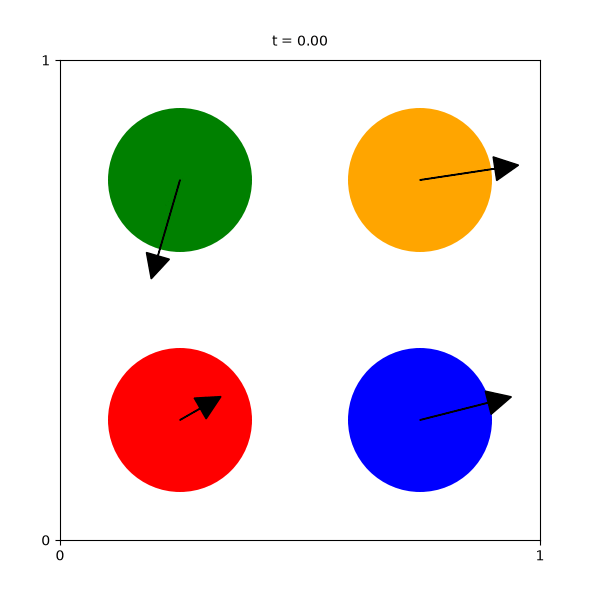

In [57]:
from IPython.display import Image

Image(filename="figures/event_disks_box_movie/animation.gif")

###  Cadenas de Markov — N = 4

A diferencia del muestreo directo, donde cada configuración se genera desde cero e
independientemente de la anterior, el muestreo por cadenas de Markov parte de una
única configuración inicial válida —aquí se define una configuracion L— y la
va modificando mediante pequeños desplazamientos aleatorios, generando
así una secuencia (cadena) de configuraciones donde cada una depende únicamente de
la anterior. El programa mantiene los parámetros físicos ya conocidos ($\sigma$
como radio de los discos, `del_xy` como tolerancia para el conteo de hits) y añade
dos parámetros propios del método: `delta`, la amplitud máxima del desplazamiento
propuesto en cada paso, y `n_steps`, el número de pasos de la cadena (equivalente,
en este contexto, a `n_runs` del muestreo directo).

El corazón del método está en las líneas donde se propone y evalúa un movimiento.
Primero, `a = random.choice(L)` selecciona **un solo disco al azar** de entre los
$N$ que conforman la configuración actual. Luego, `b = [a[0] + random.uniform(-delta, delta),
a[1] + random.uniform(-delta, delta)]` propone una nueva posición para ese disco,
desplazándolo una cantidad aleatoria pequeña (entre $-\delta$ y $+\delta$) en cada
coordenada respecto a su posición actual `a`; esta propuesta `b` es lo que en el
lenguaje de cadenas de Markov se conoce como el *estado propuesto*, y aún no se ha
aceptado como parte de la cadena.

Antes de aceptar este movimiento, el programa verifica que la nueva posición `b`
siga respetando las condiciones físicas del sistema. `min_dist` calcula la distancia
al cuadrado entre la posición propuesta `b` y todos los demás discos `c` de la
configuración (excluyendo al propio disco `a`, mediante `if c != a`), para luego
compararla con `4.0 * sigma_sq` (es decir, $(2\sigma)^2$): esta es la misma
condición de no traslape usada en el muestreo directo, solo que expresada en
distancia al cuadrado para evitar el costo computacional de una raíz cuadrada.
`box_cond` verifica que el disco propuesto no atraviese ninguna
pared de la caja. El movimiento se acepta —`a[:] = b`, reemplazando en el lugar las
coordenadas del disco original por las de la propuesta— únicamente si **ninguna**
de las dos condiciones de rechazo se cumple, es decir, si la propuesta no colisiona
con otro disco ni con las paredes (`if not (box_cond or min_dist < 4.0 * sigma_sq)`).
Si el movimiento no cumple estas condiciones, simplemente se descarta y la cadena
permanece en la configuración anterior para el siguiente paso: a diferencia del
muestreo directo, aquí un "rechazo" no implica volver a intentar generar una
configuración completa, sino que la cadena avanza sin cambios y ese mismo estado se
cuenta de nuevo como parte de la secuencia.

Después de cada paso (se acepte o no el movimiento), se reutiliza exactamente la
misma lógica del muestreo directo para verificar si la configuración actual `L`
coincide, dentro de la tolerancia `del_xy`, con alguna de las configuraciones de
referencia $a$, $b$, $c$: se recorre cada `pos_ref` de la configuración de
referencia, se busca el disco más cercano en `L` mediante la distancia tipo
Chebyshev, y se acumula la condición booleana en `condition_hit`, incrementando
`hits[conf]` si los $N$ discos de la referencia tienen un disco correspondiente
suficientemente cerca. La diferencia clave respecto al muestreo directo es que aquí
esta verificación se hace en **cada uno de los `n_steps` pasos de una misma cadena
correlacionada**, y no sobre configuraciones independientes recién generadas.

In [38]:
import pandas as pd

# 1. Cargar el archivo con las 3 repeticiones por intento
df = pd.read_csv("data/resultados_mcmc_N4_1e4.csv")

# 2. Reorganizar la tabla pivoteando la columna 'Intento' hacia las columnas
df_pivot = df.pivot(
    index="Configuracion",
    columns="Intento",
    values=["Hits", "Probabilidad_Estimada"],
)

# 3. Extraer el valor de N_runs (como es el mismo para todas, lo usamos para el título)
n_runs_val = df["N_runs"].iloc[0]

# 4. Aplanar el encabezado multinivel para tener nombres de columnas limpios
df_pivot.columns = [
    "Hits (Intento 1)",
    "Hits (Intento 2)",
    "Hits (Intento 3)",
    "P (Intento 1)",
    "P (Intento 2)",
    "P (Intento 3)",
]

# 5. Calcular la media y desviación estándar de los hits y la probabilidad a través de las columnas
df_pivot["Media Hits"] = df_pivot[
    ["Hits (Intento 1)", "Hits (Intento 2)", "Hits (Intento 3)"]
].mean(axis=1)

df_pivot["Probabilidad Media (P)"] = df_pivot[
    ["P (Intento 1)", "P (Intento 2)", "P (Intento 3)"]
].mean(axis=1)

# 6. Resetear el índice para que 'Configuracion' sea una columna normal
df_final = df_pivot.reset_index()

# 7. Renderizar la tabla con Pandas Style
df_final.style.set_caption(
    f"<b>Tabla 1:</b> Resultados de Cadena de Markov para N_{{runs}} = {n_runs_val:,} (N=4)"
).format(
    {
        "Hits (Intento 1)": "{:,.0f}",
        "Hits (Intento 2)": "{:,.0f}",
        "Hits (Intento 3)": "{:,.0f}",
        "Media Hits": "{:,.1f}",
        "P (Intento 1)": "{:.6f}",
        "P (Intento 2)": "{:.6f}",
        "P (Intento 3)": "{:.6f}",
        "Probabilidad Media (P)": "{:.6f}",
    }
).hide(axis="index")

Configuracion,Hits (Intento 1),Hits (Intento 2),Hits (Intento 3),P (Intento 1),P (Intento 2),P (Intento 3),Media Hits,Probabilidad Media (P)
Configuración A,4,0,0,0.000400,0.000000,0.000000,1.3,0.000133
Configuración B,3,0,3,0.000300,0.000000,0.000300,2.0,0.000200
Configuración C,0,6,0,0.000000,0.000600,0.000000,2.0,0.000200


In [39]:
import pandas as pd

# 1. Cargar el archivo con las 3 repeticiones por intento
df = pd.read_csv("data/resultados_mcmc_N4_1e5.csv")

# 2. Reorganizar la tabla pivoteando la columna 'Intento' hacia las columnas
df_pivot = df.pivot(
    index="Configuracion",
    columns="Intento",
    values=["Hits", "Probabilidad_Estimada"],
)

# 3. Extraer el valor de N_runs (como es el mismo para todas, lo usamos para el título)
n_runs_val = df["N_runs"].iloc[0]

# 4. Aplanar el encabezado multinivel para tener nombres de columnas limpios
df_pivot.columns = [
    "Hits (Intento 1)",
    "Hits (Intento 2)",
    "Hits (Intento 3)",
    "P (Intento 1)",
    "P (Intento 2)",
    "P (Intento 3)",
]

# 5. Calcular la media y desviación estándar de los hits y la probabilidad a través de las columnas
df_pivot["Media Hits"] = df_pivot[
    ["Hits (Intento 1)", "Hits (Intento 2)", "Hits (Intento 3)"]
].mean(axis=1)

df_pivot["Probabilidad Media (P)"] = df_pivot[
    ["P (Intento 1)", "P (Intento 2)", "P (Intento 3)"]
].mean(axis=1)

# 6. Resetear el índice para que 'Configuracion' sea una columna normal
df_final = df_pivot.reset_index()

# 7. Renderizar la tabla con Pandas Style
df_final.style.set_caption(
    f"<b>Tabla 2:</b> Resultados de Cadena de Markov para N_{{runs}} = {n_runs_val:,} (N=4)"
).format(
    {
        "Hits (Intento 1)": "{:,.0f}",
        "Hits (Intento 2)": "{:,.0f}",
        "Hits (Intento 3)": "{:,.0f}",
        "Media Hits": "{:,.1f}",
        "P (Intento 1)": "{:.6f}",
        "P (Intento 2)": "{:.6f}",
        "P (Intento 3)": "{:.6f}",
        "Probabilidad Media (P)": "{:.6f}",
    }
).hide(axis="index")

Configuracion,Hits (Intento 1),Hits (Intento 2),Hits (Intento 3),P (Intento 1),P (Intento 2),P (Intento 3),Media Hits,Probabilidad Media (P)
Configuración A,18,10,5,0.000180,0.000100,0.000050,11.0,0.000110
Configuración B,18,13,24,0.000180,0.000130,0.000240,18.3,0.000183
Configuración C,18,2,20,0.000180,0.000020,0.000200,13.3,0.000133


In [40]:
import pandas as pd

# 1. Cargar el archivo con las 3 repeticiones por intento
df = pd.read_csv("data/resultados_mcmc_N4_1e6.csv")

# 2. Reorganizar la tabla pivoteando la columna 'Intento' hacia las columnas
df_pivot = df.pivot(
    index="Configuracion",
    columns="Intento",
    values=["Hits", "Probabilidad_Estimada"],
)

# 3. Extraer el valor de N_runs (como es el mismo para todas, lo usamos para el título)
n_runs_val = df["N_runs"].iloc[0]

# 4. Aplanar el encabezado multinivel para tener nombres de columnas limpios
df_pivot.columns = [
    "Hits (Intento 1)",
    "Hits (Intento 2)",
    "Hits (Intento 3)",
    "P (Intento 1)",
    "P (Intento 2)",
    "P (Intento 3)",
]

# 5. Calcular la media y desviación estándar de los hits y la probabilidad a través de las columnas
df_pivot["Media Hits"] = df_pivot[
    ["Hits (Intento 1)", "Hits (Intento 2)", "Hits (Intento 3)"]
].mean(axis=1)

df_pivot["Probabilidad Media (P)"] = df_pivot[
    ["P (Intento 1)", "P (Intento 2)", "P (Intento 3)"]
].mean(axis=1)

# 6. Resetear el índice para que 'Configuracion' sea una columna normal
df_final = df_pivot.reset_index()

# 7. Renderizar la tabla con Pandas Style
df_final.style.set_caption(
    f"<b>Tabla 3:</b> Resultados de Cadena de Markov para N_{{runs}} = {n_runs_val:,} (N=4)"
).format(
    {
        "Hits (Intento 1)": "{:,.0f}",
        "Hits (Intento 2)": "{:,.0f}",
        "Hits (Intento 3)": "{:,.0f}",
        "Media Hits": "{:,.1f}",
        "P (Intento 1)": "{:.6f}",
        "P (Intento 2)": "{:.6f}",
        "P (Intento 3)": "{:.6f}",
        "Probabilidad Media (P)": "{:.6f}",
    }
).hide(axis="index")

Configuracion,Hits (Intento 1),Hits (Intento 2),Hits (Intento 3),P (Intento 1),P (Intento 2),P (Intento 3),Media Hits,Probabilidad Media (P)
Configuración A,131,102,96,0.000131,0.000102,0.000096,109.7,0.000110
Configuración B,121,128,109,0.000121,0.000128,0.000109,119.3,0.000119
Configuración C,108,151,127,0.000108,0.000151,0.000127,128.7,0.000129


In [41]:
# Cargar el DataFrame desde el archivo CSV que guardaste
import pandas as pd
from src.prueba import probar_equiprobabilidad

df_hits = pd.read_csv("data/resultados_mcmc_N4_1e6.csv")

# Ejecutar la prueba de hipótesis directamente con tu DataFrame
resultado = probar_equiprobabilidad(df_hits)

      PRUEBA DE HIPÓTESIS DE EQUIPROBABILIDAD DE ESTADOS
  Configuración  Hits Observados  Hits Esperados (H0)  Prob. Observada  Prob. Teórica (H0)
Configuración A              329               357.67           0.3066              0.3333
Configuración B              358               357.67           0.3336              0.3333
Configuración C              386               357.67           0.3597              0.3333
------------------------------------------------------------
Total de Hits Evaluados (N) : 1073
Prueba Chi-Cuadrado (χ²)    : Estadística = 4.5424, p-valor = 0.1032
Nivel de Significancia (α)  : 0.05
Veredicto Final             : NO SE RECHAZA H0 (Equiprobable)


Al igual que en el muestreo directo, con $n_{\text{steps}}=10^4$ los hits son muy
pocos y muy dispersos entre intentos (por ejemplo, la Configuración A pasa de 4 a 0
hits), por lo que no se puede sacar ninguna conclusión confiable sobre
equiprobabilidad a ese nivel. Al aumentar a $10^5$ y sobre todo a $10^6$ pasos, las
medias de hits de las tres configuraciones se acercan bastante entre sí (109.7,
119.3 y 128.7 para $10^6$), y las probabilidades medias estimadas quedan en un
rango similar. Esto sugiere que, también con cadenas
de Markov, el sistema tiende hacia la equiprobabilidad a medida que se aumenta el
número de pasos, aunque las diferencias relativas entre configuraciones parecen
algo mayores que las obtenidas con muestreo directo para el mismo número de
corridas.

La probabilidad se estima de la misma manera que antes: como la fracción de pasos
en los que la configuración actual de la cadena cayó dentro de la tolerancia de
cada configuración de referencia, $P(\text{conf}) \approx
\text{hits}(\text{conf})/n_{\text{steps}}$.

Comparando ambos métodos para $N=4$ y $10^6$ corridas, el muestreo directo dio
medias de hits de 111.7, 109.7 y 118.0, mientras que las cadenas de Markov dieron
109.7, 119.3 y 128.7: los órdenes de magnitud y las probabilidades medias son
comparables entre los dos métodos, lo cual es consistente, ya que ambos deberían
converger al mismo resultado si el sistema es efectivamente equiprobable. Sin
embargo, las fluctuaciones entre los tres intentos independientes son notoriamente
mayores en las cadenas de Markov que en el muestreo directo: en la Tabla 6
($10^5$), por ejemplo, la Configuración C varía entre 2 y 20 hits según el intento,
una dispersión relativa mucho más grande que la vista en el muestreo directo para
el mismo `n_runs`. Esto tiene sentido físicamente, ya que en una cadena de Markov
los estados consecutivos están correlacionados (cada configuración depende de la
anterior), por lo que la cadena tiende a "quedarse" more tiempo cerca de ciertas
regiones del espacio de configuraciones antes de explorar otras, generando mayor
varianza entre corridas independientes que el muestreo directo, donde cada
configuración es completamente independiente de la anterior.

### Cadenas de Markov — N = 8

El código para $N=8$ sigue exactamente la misma lógica de cadena de Markov ya
explicada para $N=4$ (propuesta de desplazamiento de un disco aleatorio, criterio
de aceptación/rechazo por traslape y paredes, y verificación de hits en cada paso),
por lo que no se repite su explicación. Los cambios son consistentes con los ya
introducidos en el muestreo directo para $N=8$: se usa $\sigma=0.10$, las tres
configuraciones de referencia $a$, $b$, $c$ ya no se definen manualmente sino que
se cargan desde el archivo `configuraciones_ref_N8.json` generado previamente (para
usar las mismas referencias aleatorias en ambos métodos), y la configuración
inicial de la cadena `L` ya no son las esquinas fijas de la caja, sino que se genera
llamando a `direct_disks_box(8, sigma)`, la misma función de muestreo directo, para
garantizar una configuración inicial válida sin traslapes entre los 8 discos. El
único parámetro nuevo que cambia es `delta`, reducido de 0.1 a 0.05: al haber más
discos y, por tanto, más restricciones de espacio disponible, un paso de
desplazamiento más pequeño reduce la probabilidad de proponer movimientos que
choquen con otro disco, lo que ayuda a que la cadena acepte movimientos con mayor
frecuencia.

In [44]:
import pandas as pd

# 1. Cargar el archivo con las 3 repeticiones por intento
df = pd.read_csv("data/resultados_mcmc_N8_1e6.csv")

# 2. Reorganizar la tabla pivoteando la columna 'Intento' hacia las columnas
df_pivot = df.pivot(
    index="Configuracion",
    columns="Intento",
    values=["Hits", "Probabilidad_Estimada"],
)

# 3. Extraer el valor de N_runs (como es el mismo para todas, lo usamos para el título)
n_runs_val = df["N_runs"].iloc[0]

# 4. Aplanar el encabezado multinivel para tener nombres de columnas limpios
df_pivot.columns = [
    "Hits (Intento 1)",
    "Hits (Intento 2)",
    "Hits (Intento 3)",
    "P (Intento 1)",
    "P (Intento 2)",
    "P (Intento 3)",
]

# 5. Calcular la media y desviación estándar de los hits y la probabilidad a través de las columnas
df_pivot["Media Hits"] = df_pivot[
    ["Hits (Intento 1)", "Hits (Intento 2)", "Hits (Intento 3)"]
].mean(axis=1)

df_pivot["Probabilidad Media (P)"] = df_pivot[
    ["P (Intento 1)", "P (Intento 2)", "P (Intento 3)"]
].mean(axis=1)

# 6. Resetear el índice para que 'Configuracion' sea una columna normal
df_final = df_pivot.reset_index()

# 7. Renderizar la tabla con Pandas Style
df_final.style.set_caption(
    f"<b>Tabla 10:</b> Resultados de Cadena de Markov para N_{{runs}} = {n_runs_val:,} (N=8)"
).format(
    {
        "Hits (Intento 1)": "{:,.0f}",
        "Hits (Intento 2)": "{:,.0f}",
        "Hits (Intento 3)": "{:,.0f}",
        "Media Hits": "{:,.1f}",
        "P (Intento 1)": "{:.6f}",
        "P (Intento 2)": "{:.6f}",
        "P (Intento 3)": "{:.6f}",
        "Probabilidad Media (P)": "{:.6f}",
    }
).hide(axis="index")

Configuracion,Hits (Intento 1),Hits (Intento 2),Hits (Intento 3),P (Intento 1),P (Intento 2),P (Intento 3),Media Hits,Probabilidad Media (P)
Configuración A,0,0,0,0.000000,0.000000,0.000000,0.0,0.000000
Configuración B,0,0,0,0.000000,0.000000,0.000000,0.0,0.000000
Configuración C,0,0,0,0.000000,0.000000,0.000000,0.0,0.000000


## comparasao

In [45]:
import pandas as pd

# 1. Cargar el archivo CSV con los resultados
df = pd.read_csv("data/Tabla_comparativa.csv")

# 2. Extraer el valor de N Muestras para el título
n_muestras_val = df["N Muestras"].iloc[0]

# 3. Renderizar la tabla usando la misma estructura de Pandas Style
df.style.set_caption(
    f"<b>Tabla 11:</b> Comparación de Métodos de Muestreo para N Muestras = {n_muestras_val:,}"
).format(
    {
        "N Muestras": "{:,.0f}",
        "Hits Totales": "{:,.0f}",
        "Prob. Estimada": "{:.2e}",
        "Error Estándar": "{:.2e}",
        "Tiempo Ejecución (s)": "{:.3f}",
        "Muestras / Seg": "{:,.1f}",
    }
).hide(axis="index")

Método,N Muestras,Hits Totales,Prob. Estimada,Error Estándar,Tiempo Ejecución (s),Muestras / Seg
Muestreo Directo,"1,000,000",13,1.30e-05,3.61e-06,96.730,"10,338.0"
MCMC Metropolis,"1,000,000",8,8.00e-06,2.83e-06,10.216,"97,888.5"



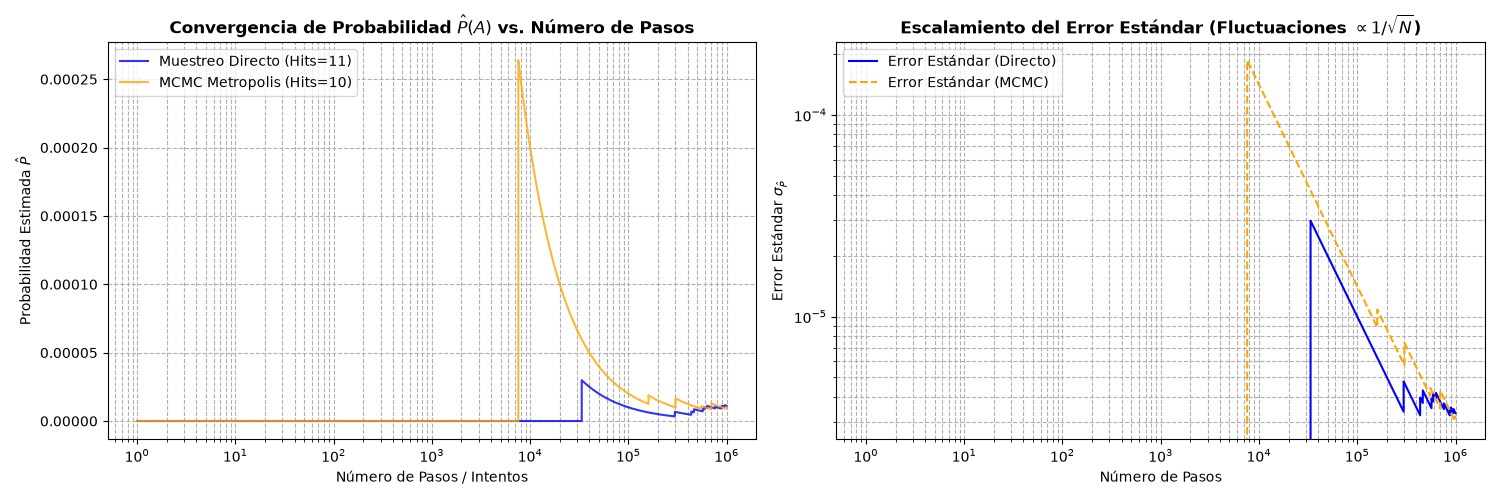

In [46]:
from IPython.display import HTML
import base64

with open("figures/comparacion/Comparacion_ds_mcmc.png", "rb") as f:
    data = base64.b64encode(f.read()).decode("utf-8")

HTML(f'<img src="data:image/gif;base64,{data}" width="1000">')

## 4.3. Muestreo basado en eventos

### Muestreo basado en eventos (Dinámica Molecular)

Aquí los discos tienen una velocidad real
$(v_x,v_y)$ y se mueven en línea recta hasta que ocurre una **colisión**, ya sea
contra una pared o contra otro disco; en ese instante la velocidad se actualiza
según las leyes de choque elástico y el sistema continúa, en vez de avanzar en pasos de tiempo fijos, el
programa salta directamente de un evento (colisión) al siguiente.

La función `wall_time` calcula, para un disco y un eje dados, el tiempo que falta
para chocar con la pared correspondiente: si la velocidad es positiva, se calcula el
tiempo para llegar a la pared derecha/superior (`1.0 - sigma`); si es negativa, el
tiempo para llegar a la pared izquierda/inferior (`sigma`); y si es cero, el disco
nunca choca en ese eje (`inf`). La función `pair_time` calcula, de forma analítica,
el tiempo hasta que dos discos choquen entre sí: a partir de la posición y velocidad
relativas entre ambos, resuelve la ecuación cuadrática que determina cuándo la
distancia entre sus centros será exactamente $2\sigma$ (condición de contacto). Solo
existe una colisión futura real si el discriminante `Upsilon` es positivo (hay
solución) y `scal < 0` (los discos se están acercando); en caso contrario, el tiempo
es infinito.

En el bucle principal, en cada iteración se calculan los tiempos hasta todas las
posibles colisiones —de cada disco con cada pared (`wall_times`) y entre cada par
de discos (`pair_times`)— y se toma el mínimo de todos ellos (`next_event`): ese es
el próximo evento que realmente ocurrirá. Antes de saltar a ese instante, el
programa avanza las posiciones en pasos de tiempo *enteros* (el bucle sobre
`inter_times`) únicamente para poder registrar, en esos instantes regulares, si la
configuración actual coincide con $a$, $b$ o $c$ —reutilizando la misma lógica de
`condition_b`/`condition_hit` ya vista—, de manera análoga a un muestreo por
"fotografías" periódicas del sistema en movimiento. Luego el reloj `t` avanza
exactamente hasta el instante del evento y las posiciones se actualizan por
movimiento rectilíneo uniforme ($r = r + v\,\Delta t$).

Finalmente, se actualizan las velocidades según el tipo de colisión: si fue contra
una pared, simplemente se invierte la componente de velocidad en ese eje
(`vel *= -1.0`, rebote elástico); si fue entre dos discos, se calcula el vector
normal a la línea que une sus centros (`e_perp`) y se transfiere el impulso a lo
largo de esa dirección a cada disco en sentidos opuestos, aplicando conservación de
momento lineal y energía cinética propias de un choque elástico. El proceso se
repite por `n_events` colisiones, acumulando en `hits` cuántas veces, en los
instantes de muestreo, el sistema pasó cerca de cada configuración de referencia.

In [47]:
import json
import pandas as pd

# 1. Cargar el archivo JSON
with open("data/resultados_ev_N4.json", "r") as f:
    data = json.load(f)

# 2. Extraer n_samples y estructurar los datos por configuración
n_samples = data["n_samples"]

registros = [
    {"Configuracion": "Configuración A", "Hits": data["a"], "Probabilidad (P)": data["a"] / n_samples},
    {"Configuracion": "Configuración B", "Hits": data["b"], "Probabilidad (P)": data["b"] / n_samples},
    {"Configuracion": "Configuración C", "Hits": data["c"], "Probabilidad (P)": data["c"] / n_samples},
]

df = pd.DataFrame(registros)

# 3. Renderizar con Pandas Style
df.style.set_caption(
    f"<b>Tabla 1:</b> Resultados de Muestreo para N_samples = {n_samples:,}"
).format(
    {
        "Hits": "{:,.0f}",
        "Probabilidad (P)": "{:.6f}",
    }
).hide(axis="index")

Configuracion,Hits,Probabilidad (P)
Configuración A,361,0.000983
Configuración B,398,0.001084
Configuración C,366,0.000996


In [48]:
# 1. Leer el archivo JSON
import json
from src.prueba import probar_equiprobabilidad
with open("data/resultados_ev_N4.json", "r") as f:
    datos_json = json.load(f)

# 2. Extraer únicamente los aciertos de las configuraciones
hits_dict = {
    "Configuración A": datos_json["a"],
    "Configuración B": datos_json["b"],
    "Configuración C": datos_json["c"],
}

# 3. Correr la prueba de hipótesis
resultado = probar_equiprobabilidad(hits_dict)

      PRUEBA DE HIPÓTESIS DE EQUIPROBABILIDAD DE ESTADOS
  Configuración  Hits Observados  Hits Esperados (H0)  Prob. Observada  Prob. Teórica (H0)
Configuración A              361                375.0           0.3209              0.3333
Configuración B              398                375.0           0.3538              0.3333
Configuración C              366                375.0           0.3253              0.3333
------------------------------------------------------------
Total de Hits Evaluados (N) : 1125
Prueba Chi-Cuadrado (χ²)    : Estadística = 2.1493, p-valor = 0.3414
Nivel de Significancia (α)  : 0.05
Veredicto Final             : NO SE RECHAZA H0 (Equiprobable)


Con $n_{\text{events}}=3{,}000{,}000$ colisiones simuladas se obtuvieron 367,309
muestras registradas en los instantes enteros de tiempo. El número de hits para las
tres configuraciones de referencia resultó comparable entre sí (361, 398 y 366
para $a$, $b$ y $c$ respectivamente), con probabilidades estimadas del orden de
$0.001$ y diferencias relativas menores al 10 % entre configuraciones, lo cual es
consistente con la equiprobabilidad observada previamente mediante los otros dos
métodos de muestreo.

Para construir el histograma de posiciones, el código añade un arreglo bidimensional
`hist2d` de tamaño `n_bins x n_bins` que discretiza la caja en una rejilla de
celdas. Cada vez que se registra una muestra de posiciones (en los mismos instantes
enteros de tiempo usados para contar hits), se recorre cada uno de los 4 discos y se
determina en qué celda de la rejilla cae su centro, convirtiendo la coordenada
continua $(x,y) \in [0,1]^2$ en un índice entero `(ix, iy)` mediante `int(a[0]*n_bins)`
y `int(a[1]*n_bins)`; esa celda del histograma se incrementa en uno. Al final de la
simulación, `hist2d` contiene, para cada celda de la rejilla, el número total de
veces que algún disco fue observado ahí a lo largo de todos los eventos, lo cual se
guarda en disco (`histpos.npy`) para graficarlo posteriormente.

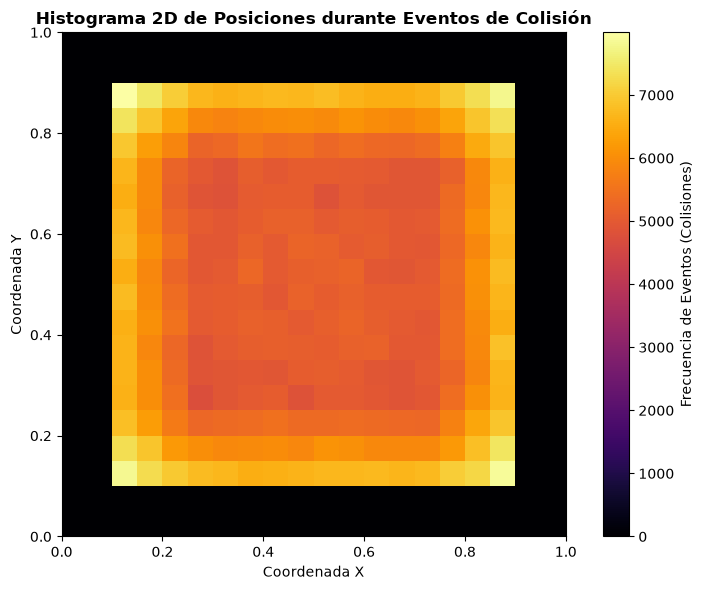

In [55]:
# --- CARGAR Y MOSTRAR HISTOGRAMA 2D ---

import numpy as np
hist2d = np.load("data/histpos.npy")

plt.figure(figsize=(8, 6))

# Graficar el mapa de calor a partir de la matriz de histograma cargada
plt.imshow(
    hist2d.T,
    origin="lower",
    extent=[0, 1, 0, 1],
    cmap="inferno",
    aspect="equal",
    )
plt.colorbar(label="Frecuencia de Eventos (Colisiones)")

plt.title(
    "Histograma 2D de Posiciones durante Eventos de Colisión",
    fontsize=12,
    fontweight="bold",
    )
plt.xlabel("Coordenada X")
plt.ylabel("Coordenada Y")

plt.tight_layout()
plt.show()

El histograma 2D muestra una región central homogénea, con frecuencias de colisión
relativamente uniformes (tonos naranja/rojo, entre 4000 y 6000 aproximadamente) en
la mayor parte de la caja accesible, y dos anillos bien diferenciados: una franja
completamente negra en los bordes (entre 0 y $\sigma=0.10$, y entre $0.90$ y $1.0$),
donde la frecuencia es exactamente cero, y un anillo brillante justo por dentro de
esa franja prohibida, con las frecuencias más altas del histograma (hasta
$\sim$7000-7500, visibles como los tonos amarillos en las esquinas y bordes de la
región permitida). La franja negra exterior es simplemente la zona geométricamente
inaccesible para el centro de un disco de radio $\sigma$: como el centro nunca
puede estar a menos de $\sigma$ de una pared, esa región nunca se puebla, sin
importar cuántos eventos se simulen. El anillo brillante inmediatamente adyacente
se debe a que las colisiones con las paredes ocurren precisamente en esa frontera
($x=\sigma$, $x=1-\sigma$, etc.): como el sistema pasa relativamente más tiempo
cerca de las paredes (los discos se mueven, rebotan y a menudo quedan cerca del
borde justo antes o después de un choque), esas celdas acumulan más muestras que el
interior. En conjunto, el histograma evidencia que la distribución de posiciones
**no es uniforme** dentro de la región accesible: aunque el centro de la caja
muestra una densidad razonablemente pareja, existe un exceso claro de densidad cerca
de los bordes permitidos, un efecto puramente geométrico asociado al tamaño finito
de los discos y a la naturaleza de las colisiones con las paredes, y no una
violación del postulado de equiprobabilidad de microestados completos.

## 4.4 Histograma de posiciones

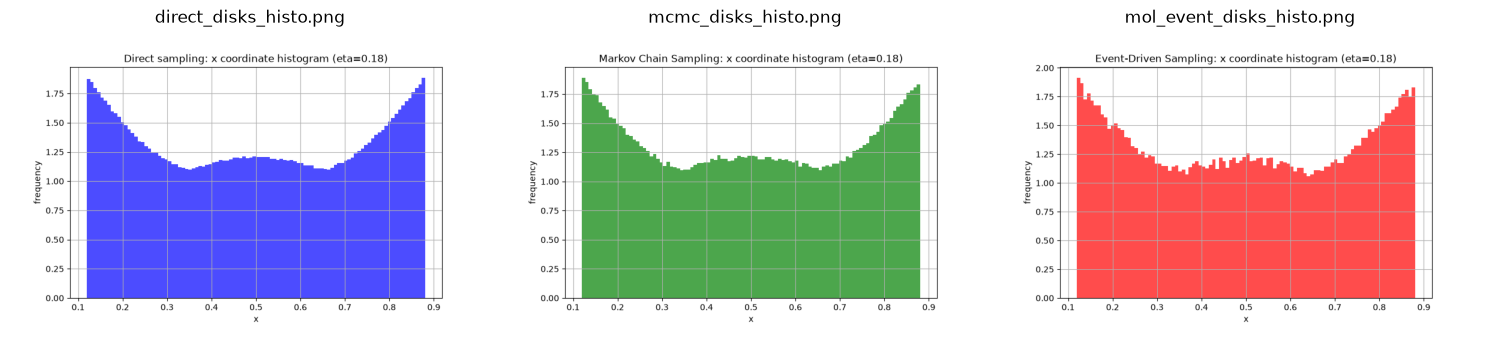

In [ ]:
#Histiograma para Muestreo directo
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

carpeta = "figures"
archivos = sorted([f for f in os.listdir(carpeta) if f.lower().endswith(".png")])

# Mostrar en una cuadrícula (por ejemplo, 3 columnas)
n = len(archivos)
cols = 3
filas = (n + cols - 1) // cols

fig, axes = plt.subplots(filas, cols, figsize=(15, 5 * filas))
axes = axes.flatten() if n > 1 else [axes]

for ax, archivo in zip(axes, archivos):
    img = mpimg.imread(os.path.join(carpeta, archivo))
    ax.imshow(img)
    ax.set_title(archivo)
    ax.axis("off")

# Ocultar ejes sobrantes
for ax in axes[n:]:
    ax.axis("off")

plt.tight_layout()
plt.show()

# 5. Conclusiones


# 6. Bibliografía

# 7. Agradecimientos

Agradecimientos a Manu, a Guisao, a Sepulveda y a su mascota el camaleon por su incondicional apoyo y compañia durante las largas noches de sufrimiento y agonia que destruyeron poco a poco mi espiritu y alma hasta llevarme al colapso y al borde de un vacio inconmensurable.